#### DeePMD calculator for [torch-sim](https://github.com/torchsim/torch-sim)

<img src="input/water.png" width="270" align="right" style="margin-left: 20px;">

Cross-check of the DeePMD-kit water model evaluated two independent ways:

- **`deepmd_torchsim.DeepmdModel`** - the torch-sim `ModelInterface` model
- **`deepmd.calculator.DP`** - DeePMD-kit's own ASE calculator (reference)

**Test system.** A cubic water box of 64 H₂O molecules (192 atoms). All
calculations use `float64` to expose differences.

**Model.** A DeePMD-kit model (`input/frozen_model.pth`, TorchScript)
trained on liquid water.


In [1]:
import os, sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd

In [2]:
import torch
from ase.io import read
import torch_sim as ts
from deepmd_torchsim import DeepmdModel  # TorchSim DeePMD
from deepmd.calculator import DP         # ASE DeePMD

Warp CUDA error 100: no CUDA-capable device is detected (in function init_cuda_driver, /builds/omniverse/warp/warp/native/cuda_util.cpp:333)


In [39]:
# help(DeepmdModel)

In [4]:
prefix_path = os.getcwd()
print(prefix_path)

/home/rverma7/deepmd_torchsim_work/deepmd_torchsim/validation


In [5]:
# setting plot syle
plt.rcParams.update({
    'text.color': 'darkblue',
    'axes.labelcolor': 'darkblue',
    'xtick.color': 'gray',
    'ytick.color': 'gray',
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'font.size': 15,
    'grid.linestyle': '-.',
})

In [6]:
MODEL_PATH = os.path.join(prefix_path, "input", "frozen_model.pth")
INPUT_FILE = os.path.join(prefix_path, "input" ,"water_192atoms.xyz")

print(f"DeePMD Model Name: {MODEL_PATH}")
print(f"Input FileName: {INPUT_FILE}")

DeePMD Model Name: /home/rverma7/deepmd_torchsim_work/deepmd_torchsim/validation/input/frozen_model.pth
Input FileName: /home/rverma7/deepmd_torchsim_work/deepmd_torchsim/validation/input/water_192atoms.xyz


In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

print(f"Running Calculation in '{DEVICE}'")

Running Calculation in 'cuda'


```bash
#############################################################################
# TorchSim DeepPotential Calculator
#############################################################################
```

In [8]:
def run_torchsim(atoms) -> dict:
    """torch_sim.ModelInterface via DeepmdModel."""
    model = DeepmdModel(
        model_path=MODEL_PATH,
        device=DEVICE,
        dtype=DTYPE,
        compute_forces=True,
        compute_stress=True,
    )
    state = ts.io.atoms_to_state([atoms], DEVICE, DTYPE)
    out = model(state)
    return {
        "energy_eV": out["energy"][0].item(),
        "forces_eV_per_A": out["forces"].detach().cpu().numpy().tolist(),
        "stress_eV_per_A3": out["stress"][0].detach().cpu().numpy().tolist(),
    }

```bash
#############################################################################
# ASE DeepPotential Calculator
#############################################################################
```

In [9]:
def run_ase(atoms) -> dict:
    """DeePMD-kit's own ASE calculator (ground truth reference)."""
    from deepmd.calculator import DP

    atoms = atoms.copy()
    atoms.calc = DP(model=str(MODEL_PATH))
    return {
        "energy_eV": float(atoms.get_potential_energy()),
        "forces_eV_per_A": atoms.get_forces().tolist(),
        "stress_eV_per_A3": atoms.get_stress(voigt=False).tolist(),
    }

#### 1. Static benchmark - energy, and forces, and stress


In [10]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Input structure not found at {INPUT_FILE}")


atoms = read(INPUT_FILE)
print(f"Loaded {len(atoms)}-atom structure from {INPUT_FILE}")
print(f"Loaded model from {MODEL_PATH}, running on device={DEVICE}")

print("\nRunning torch-sim DeepmdModel...")
ts_out = run_torchsim(atoms)
print(f"  energy = {ts_out['energy_eV']:.6f} eV")

print("Running ASE deepmd.calculator.DP (reference)...")
ase_out = run_ase(atoms)
print(f"  energy = {ase_out['energy_eV']:.6f} eV")

energy_diff = abs(ts_out["energy_eV"] - ase_out["energy_eV"])
forces_diff = np.abs(np.array(ts_out["forces_eV_per_A"]) - np.array(ase_out["forces_eV_per_A"])).max()
stress_diff = np.abs(
np.array(ts_out["stress_eV_per_A3"]) - np.array(ase_out["stress_eV_per_A3"])).max()


print("\nComparison (torch-sim vs ASE reference):")
print(f"  max |energy diff|  = {energy_diff:.3e} eV")
print(f"  max |forces diff|  = {forces_diff:.3e} eV/A")
print(f"  max |stress diff|  = {stress_diff:.3e} eV/A^3")
print(f"  pass (<1e-4 abs)?  = {max(energy_diff, forces_diff, stress_diff)< 1e-4}")

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.


Loaded 192-atom structure from /home/rverma7/deepmd_torchsim_work/deepmd_torchsim/validation/input/water_192atoms.xyz
Loaded model from /home/rverma7/deepmd_torchsim_work/deepmd_torchsim/validation/input/frozen_model.pth, running on device=cuda

Running torch-sim DeepmdModel...
  energy = -29859.224584 eV
Running ASE deepmd.calculator.DP (reference)...
  energy = -29859.224584 eV

Comparison (torch-sim vs ASE reference):
  max |energy diff|  = 0.000e+00 eV
  max |forces diff|  = 1.776e-15 eV/A
  max |stress diff|  = 2.776e-16 eV/A^3
  pass (<1e-4 abs)?  = True


In [11]:
ts_out.keys()

dict_keys(['energy_eV', 'forces_eV_per_A', 'stress_eV_per_A3'])

In [12]:
ase_out.keys()

dict_keys(['energy_eV', 'forces_eV_per_A', 'stress_eV_per_A3'])

In [13]:
n_atoms = len(atoms)
n_atoms

192

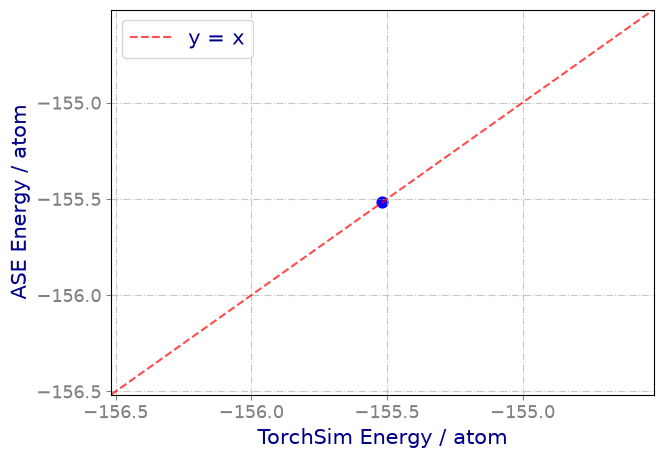

In [14]:
plt.figure(figsize=(7, 5), dpi=100)

x = ts_out['energy_eV'] / n_atoms
y = ase_out['energy_eV'] / n_atoms

plt.scatter(x, y, s=60, color='blue')

lo, hi = min(x, y), max(x, y)
pad = 1 if lo == hi else 0.05 * (hi - lo)
lims = [lo - pad, hi + pad]

plt.plot(lims, lims, 'r--', linewidth=1.5, label='y = x', alpha=0.7)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('TorchSim Energy / atom')
plt.ylabel('ASE Energy / atom')

plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)

plt.grid(ls='-.', alpha=0.7)
plt.legend()

plt.show()

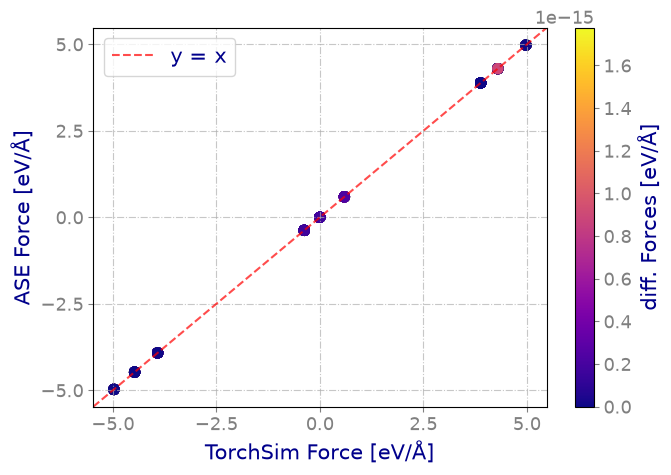

In [15]:
torchsim_forces = np.array(ts_out['forces_eV_per_A'])
ase_forces = np.array(ase_out['forces_eV_per_A'])

x = torchsim_forces.flatten()
y = ase_forces.flatten()

diff = np.abs(x - y)

plt.figure(figsize=(7, 5), dpi=100)

sc = plt.scatter(x, y, c=diff, s=50, cmap='plasma')

# y = x reference line
lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (hi - lo)
lims = [lo - pad, hi + pad]

plt.plot(lims, lims, 'r--', linewidth=1.5, alpha=0.7, label='y = x')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel(r'TorchSim Force [eV/$\mathrm{\AA}$]')
plt.ylabel(r'ASE Force [eV/$\mathrm{\AA}$]')

plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)

plt.grid(ls='-.', alpha=0.7)
plt.legend()

plt.colorbar(sc, label='diff. Forces [eV/Å]')

plt.tight_layout()
plt.show()

#### 2. Geometry optimization

**FIRE** algorithm (Fast Inertial Relaxation Engine) to a force tolerance of `fmax_target` = 0.05 eV/Å, capped at `max_steps` iterations.

The two engines use independent FIRE implementations (torch-sim `fire_init`/`fire_step` vs. `ase.optimize.FIRE`), identical trajectories are *not*  expected - instead we check that both converge to the same basin (i.e RMSD ~ 0):

$$
\Delta E_\text{final} = \bigl| E_\text{ts} - E_\text{ase} \bigr|, \qquad
\text{RMSD} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}
   \bigl\lVert \mathbf{r}^\text{ts}_i - \mathbf{r}^\text{ase}_i \bigr\rVert^2}
$$


#### FIRE Relaxation

In [16]:
from ase import Atoms, units
from ase.io import read, write
from ase.optimize import FIRE as ASE_FIRE
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet

import torch_sim as ts
from torch_sim.integrators.nve import nve_init, nve_step
from torch_sim.integrators.nvt import nvt_langevin_init, nvt_langevin_step
from torch_sim.io import atoms_to_state, state_to_atoms
from torch_sim.quantities import calc_kinetic_energy, calc_kT
from torch_sim.units import MetalUnits

In [17]:
# --- run: FIRE relaxation, both ASE and TorchSim engines ---
perturbation = 0.08   # Angstrom/atom
fmax_target = 0.05         # eV/A
max_steps = 300
seed = 0
print_stride = 1      # print a trajectory line every N FIRE steps

HEADER = f"{'step':>5} {'E (eV)':>16} {'fmax (eV/A)':>14}"

In [18]:
def perturbed_system():
    a = read(INPUT_FILE)
    rng = np.random.default_rng(seed)
    a.positions += rng.normal(scale=perturbation, size=a.positions.shape)
    return a

In [19]:
def relax_with_torchsim(initial_atoms):
    model = DeepmdModel(model_path=MODEL_PATH, device=DEVICE, dtype=DTYPE, compute_forces=True)
    fire_state = ts.optimizers.fire_init(
        state=ts.io.atoms_to_state([initial_atoms], DEVICE, DTYPE), model=model)

    print("\ntorch-sim (DeepmdModel) FIRE")
    print(HEADER)

    energy_per_step, fmax_per_step = [], []
    traj = [state_to_atoms(fire_state)[0]]
    
    for step_index in range(max_steps):
        fire_state = ts.optimizers.fire_step(state=fire_state, model=model)
        prediction = model(fire_state)
        step_energy = prediction["energy"][0].item()
        energy_per_step.append(step_energy)
        step_fmax = float(np.abs(prediction["forces"].detach().cpu().numpy()).max())
        fmax_per_step.append(step_fmax)
        traj.append(state_to_atoms(fire_state)[0])
        if (step_index + 1) % print_stride == 0 or step_fmax < fmax_target:
            print(f"{step_index + 1:>5} {step_energy:>16.6f} {step_fmax:>14.4f}")
        if step_fmax < fmax_target:
            break

    relaxed = model(fire_state)
    relaxed_forces = relaxed["forces"].detach().cpu().numpy()
    
    return {
        "final_energy_eV": relaxed["energy"][0].item(),
        "final_positions_A": fire_state.positions.detach().cpu().numpy(),
        "final_fmax_eV_per_A": float(np.abs(relaxed_forces).max()),
        "n_steps": step_index + 1,
        "energy_per_step_eV": energy_per_step,
        "fmax_per_step_eV_per_A": fmax_per_step,
        "traj": traj,
    }

In [20]:
def relax_with_ase(initial_atoms):
    relax_atoms = initial_atoms.copy()
    relax_atoms.calc = DP(model=str(MODEL_PATH))
    energy_per_step, fmax_per_step, traj = [], [], []

    def record():
        energy_per_step.append(float(relax_atoms.get_potential_energy()))
        fmax_per_step.append(float(np.abs(relax_atoms.get_forces()).max()))
        traj.append(relax_atoms.copy())
        n = len(energy_per_step)
        if n % print_stride == 0 or fmax_per_step[-1] < fmax_target:
            print(f"{n:>5} {energy_per_step[-1]:>16.6f} {fmax_per_step[-1]:>14.4f}")

    print("\nASE (deepmd.calculator.DP) FIRE")
    print(HEADER)
    optimizer = ASE_FIRE(relax_atoms, logfile=None)
    optimizer.attach(record, interval=1)
    optimizer.run(fmax=fmax_target, steps=max_steps)
    return {
        "final_energy_eV": float(relax_atoms.get_potential_energy()),
        "final_positions_A": relax_atoms.get_positions(),
        "final_fmax_eV_per_A": float(np.abs(relax_atoms.get_forces()).max()),
        "n_steps": optimizer.nsteps,
        "energy_per_step_eV": energy_per_step,
        "fmax_per_step_eV_per_A": fmax_per_step,
        "traj": traj,
    }

In [21]:
read(INPUT_FILE)

Atoms(symbols='H128O64', pbc=True, cell=[12.445, 12.445, 12.445])

In [22]:
system = read(INPUT_FILE)
torchsim_relaxation = relax_with_torchsim(initial_atoms=system)
ase_relaxation = relax_with_ase(initial_atoms=system)

geometry_rmsd = float(np.sqrt(
    ((torchsim_relaxation["final_positions_A"] - ase_relaxation["final_positions_A"]) ** 2).sum(axis=1).mean()))

print(f"\n{'':<12} {'final E (eV)':>16} {'final fmax':>12} {'steps':>7}")

for label, rlx in (("torch-sim", torchsim_relaxation), ("ASE", ase_relaxation)):
    print(f"{label:<12} {rlx['final_energy_eV']:>16.6f} "
          f"{rlx['final_fmax_eV_per_A']:>12.4f} {rlx['n_steps']:>7}")

print(f"\n|dE| {abs(torchsim_relaxation['final_energy_eV'] - ase_relaxation['final_energy_eV']):.2e} eV"
      f"  |  geometry RMSD {geometry_rmsd:.2e} A")

keep = ("final_energy_eV", "final_fmax_eV_per_A", "n_steps",
        "energy_per_step_eV", "fmax_per_step_eV_per_A")
output = {
    "torchsim": {k: torchsim_relaxation[k] for k in keep},
    "ase": {k: ase_relaxation[k] for k in keep},
}


torch-sim (DeepmdModel) FIRE
 step           E (eV)    fmax (eV/A)
    1    -29874.788921         4.0349
    2    -29887.088711         3.2468
    3    -29896.730016         2.7672
    4    -29904.150240         2.5872
    5    -29909.631521         2.4386
    6    -29913.385489         2.0151
    7    -29915.743343         1.6984
    8    -29917.408760         1.9587
    9    -29919.408641         2.2189
   10    -29922.410120         2.0870
   11    -29925.901582         1.5429
   12    -29928.621800         0.7813
   13    -29929.571669         0.2601
   14    -29929.662394         0.1650
   15    -29929.698117         0.2306
   16    -29929.718712         0.2095
   17    -29929.747762         0.1722
   18    -29929.771610         0.1279
   19    -29929.788343         0.1365
   20    -29929.808438         0.1450
   21    -29929.840125         0.1337
   22    -29929.880054         0.1065
   23    -29929.921118         0.1027
   24    -29929.956239         0.1234
   25    -29929.9983

In [23]:
output.keys()

dict_keys(['torchsim', 'ase'])

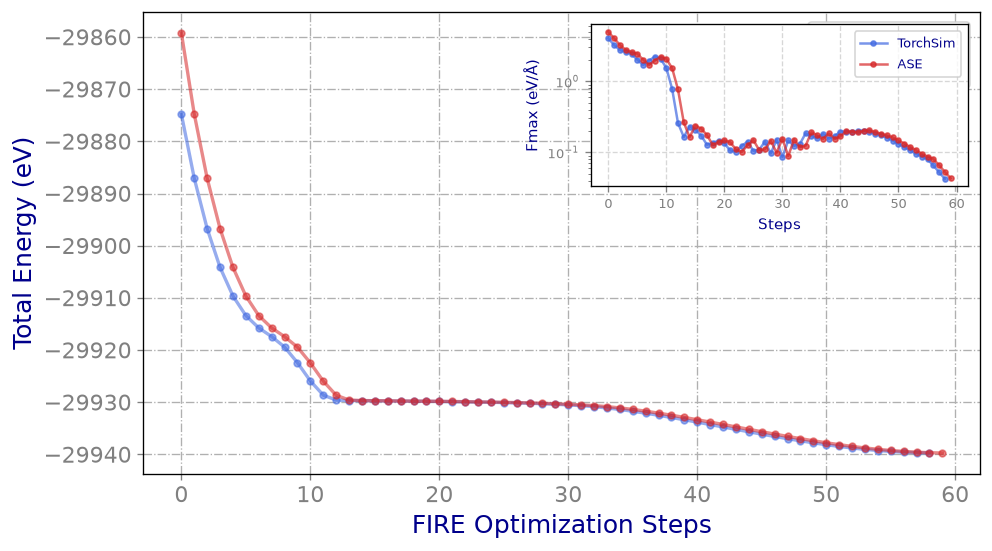

In [24]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
ax.plot(output['torchsim']['energy_per_step_eV'], label='TorchSim', lw=2, alpha=0.55, marker='o', ms=4, c='royalblue')
ax.plot(output['ase']['energy_per_step_eV'], label='ASE', lw=2, alpha=0.55, marker='o', ms=4, c='tab:red')
ax.set_xlabel('FIRE Optimization Steps')
ax.set_ylabel('Total Energy (eV)')
ax.legend(fontsize=12)
ax.grid()

axins = inset_axes(ax, width="45%", height="35%", loc='upper right')
axins.plot(output['torchsim']['fmax_per_step_eV_per_A'], lw=1.5, alpha=0.7, marker='o', ms=3, label='TorchSim', color='royalblue')
axins.plot(output['ase']['fmax_per_step_eV_per_A'], lw=1.5, alpha=0.7, marker='o', ms=3, label='ASE', color='tab:red')
axins.set_xlabel('Steps', fontsize=9)
axins.set_ylabel(r'Fmax (eV/$\mathrm{\AA}$)', fontsize=9)
axins.set_yscale('log')
axins.tick_params(axis='both', labelsize=8)
axins.grid(ls='--', alpha=0.5)
axins.legend(fontsize=8)
plt.show()

In [25]:
from ase.visualize import view

In [26]:
view(ase_relaxation['traj'], viewer='ngl')

In [27]:
view(torchsim_relaxation['traj'], viewer='ngl')


#### 3. Microcanonical molecular dynamics [NVE]

Initial momenta are drawn from a Maxwell–Boltzmann distribution and the *same* momenta are handed to both integrators. The system is propagated for `n_steps` steps of `timestep_fs` fs under constant $N$, $V$, $E$:

- **torch-sim:** velocity-Verlet via `nve_init` / `nve_step`, energies and
  temperature in `MetalUnits`.
- **ASE:** `ase.md.verlet.VelocityVerlet` on a copy carrying the `DP` calculator.

In NVE trajectory the total energy $E_\text{tot}(t) = E_\text{pot}(t) + E_\text{kin}(t)$ should be conserved.


##### NVE energy conservation

In [28]:
# --- run: NVE, both engines, shared initial momenta ---
timestep_fs = 0.5
n_steps = 5000
initial_temperature_K = 300.0
nve_seed = 42
md_stride = 20   # every N steps: print a line and write a trajectory frame

MD_HEADER = f"{'step':>6} {'PE (eV)':>15} {'KE (eV)':>11} {'E_total (eV)':>15} {'T (K)':>9}"

In [29]:
def print_md(step, pe, ke, temperature):
    print(f"{step:>6} {pe:>15.4f} {ke:>11.4f} {pe + ke:>15.4f} {temperature:>9.2f}")

def sample_initial_momenta(atoms):
    MaxwellBoltzmannDistribution(atoms, temperature_K=initial_temperature_K,
                                 rng=np.random.default_rng(nve_seed))
    return atoms.get_momenta()

def build_md_result(pe_list, ke_list, temp_list, volume):
    pe = np.array(pe_list)
    ke = np.array(ke_list)
    e_total = pe + ke
    return {
        "PE_eV": pe, "KE_eV": ke, "E_total_eV": e_total, "T_K": np.array(temp_list),
        "E_drift_eV": float(e_total.max() - e_total.min()),
        "mean_T_K": float(np.mean(temp_list)), "volume_A3": float(volume),
    }


def run_torchsim_nve(atoms, initial_momenta, trajectory_path):
    model = DeepmdModel(model_path=MODEL_PATH, device=DEVICE, dtype=DTYPE, compute_forces=True)
    state = atoms_to_state([atoms], DEVICE, DTYPE)
    state.momenta = torch.tensor(initial_momenta, dtype=DTYPE, device=DEVICE)
    kT = torch.tensor(initial_temperature_K, device=DEVICE, dtype=DTYPE) * MetalUnits.temperature
    dt = torch.tensor(timestep_fs * 0.001 * MetalUnits.time, device=DEVICE, dtype=DTYPE)
    state = nve_init(state=state, model=model, kT=kT)

    print(MD_HEADER)
    pe_list, ke_list, temp_list = [], [], []

    for step in range(n_steps):
        state = nve_step(state=state, model=model, dt=dt)
        step_pe = state.energy[0].item()
        step_ke = calc_kinetic_energy(masses=state.masses, momenta=state.momenta,
                                      system_idx=state.system_idx)[0].item()
        step_temp = calc_kT(masses=state.masses, momenta=state.momenta,
                            system_idx=state.system_idx)[0].item() / float(MetalUnits.temperature)
        pe_list.append(step_pe)
        ke_list.append(step_ke)
        temp_list.append(step_temp)

        if (step + 1) % md_stride == 0:
            print_md(step + 1, step_pe, step_ke, step_temp)
            frame = state_to_atoms(state)[0]
            frame.arrays["forces"] = model(state)["forces"].detach().cpu().numpy()
            write(trajectory_path, frame, format="extxyz", append=True)
    return build_md_result(pe_list, ke_list, temp_list, atoms.get_volume())


def run_ase_nve(atoms, initial_momenta, trajectory_path):
    atoms = atoms.copy()
    atoms.calc = DP(model=str(MODEL_PATH))
    atoms.set_momenta(initial_momenta)
    integrator = VelocityVerlet(atoms, timestep=timestep_fs * units.fs)

    print(MD_HEADER)
    pe_list, ke_list, temp_list = [], [], []
    
    for step in range(n_steps):
        integrator.run(1)
        step_pe = float(atoms.get_potential_energy())
        step_ke = float(atoms.get_kinetic_energy())
        step_temp = float(atoms.get_temperature())
        pe_list.append(step_pe)
        ke_list.append(step_ke)
        temp_list.append(step_temp)
        if (step + 1) % md_stride == 0:
            print_md(step + 1, step_pe, step_ke, step_temp)
            frame = atoms.copy()
            frame.arrays["forces"] = atoms.get_forces()
            write(trajectory_path, frame, format="extxyz", append=True)
    return build_md_result(pe_list, ke_list, temp_list, atoms.get_volume())


torchsim_traj = os.path.join(prefix_path, "output", "nve_torchsim.xyz")
ase_traj = os.path.join(prefix_path, "output", "nve_ase.xyz")

nve_atoms =  torchsim_relaxation['traj'][-1] #read(INPUT_FILE)
initial_momenta = sample_initial_momenta(nve_atoms.copy())
n_atoms = len(nve_atoms)

print(f"NVE: {n_atoms}-atom {nve_atoms.get_chemical_formula()}, {n_steps} steps, "
      f"dt {timestep_fs} fs, initial T {initial_temperature_K} K")
print("Running torch-sim NVE...")
torchsim_nve = run_torchsim_nve(nve_atoms, initial_momenta, torchsim_traj)
print("Running ASE NVE...")
ase_nve = run_ase_nve(nve_atoms, initial_momenta, ase_traj)

print(f"\n{'':<12} {'E_drift (eV)':>14} {'drift/atom (meV)':>18} {'mean T (K)':>12}")
for label, r in (("torch-sim", torchsim_nve), ("ASE", ase_nve)):
    print(f"{label:<12} {r['E_drift_eV']:>14.4e} "
          f"{1000 * r['E_drift_eV'] / n_atoms:>18.4f} {r['mean_T_K']:>12.2f}")

print(f"Saved trajectories to: \n {torchsim_traj} and \n {ase_traj}")

/tmp/ipykernel_2716939/978096899.py:5: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(atoms, temperature_K=initial_temperature_K,


NVE: 192-atom H128O64, 5000 steps, dt 0.5 fs, initial T 300.0 K
Running torch-sim NVE...
  step         PE (eV)     KE (eV)    E_total (eV)     T (K)
    20     -29937.9373      5.1500     -29932.7873    207.51
    40     -29937.0081      4.2414     -29932.7667    170.90
    60     -29938.3094      5.5167     -29932.7927    222.29
    80     -29938.7873      5.9832     -29932.8041    241.08
   100     -29939.0851      6.2953     -29932.7898    253.66
   120     -29939.5872      6.8073     -29932.7798    274.29
   140     -29940.4693      7.6806     -29932.7887    309.48
   160     -29940.9870      8.1964     -29932.7906    330.26
   180     -29941.1562      8.3679     -29932.7883    337.17
   200     -29941.1147      8.3270     -29932.7877    335.52
   220     -29941.1768      8.3867     -29932.7901    337.93
   240     -29941.0552      8.2645     -29932.7907    333.00
   260     -29941.6373      8.8455     -29932.7919    356.42
   280     -29941.2081      8.4218     -29932.7863    339

In [30]:
torchsim_nve.keys(), ase_nve.keys()

(dict_keys(['PE_eV', 'KE_eV', 'E_total_eV', 'T_K', 'E_drift_eV', 'mean_T_K', 'volume_A3']),
 dict_keys(['PE_eV', 'KE_eV', 'E_total_eV', 'T_K', 'E_drift_eV', 'mean_T_K', 'volume_A3']))

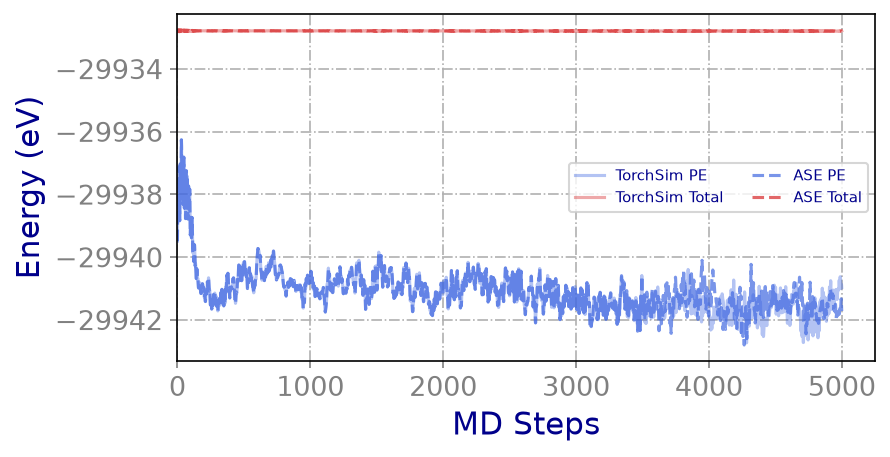

In [31]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
plt.plot(torchsim_nve['PE_eV'], label='TorchSim PE', c='royalblue', alpha=0.4)
plt.plot(torchsim_nve['E_total_eV'], label='TorchSim Total', c='tab:red', alpha=0.4)
plt.plot(ase_nve['PE_eV'], label='ASE PE', c='royalblue', ls='--', alpha=0.7)
plt.plot(ase_nve['E_total_eV'], label='ASE Total', c='tab:red', ls='--', alpha=0.7)
plt.xlim(0, None)
plt.xlabel('MD Steps')
plt.ylabel('Energy (eV)')
plt.legend(fontsize=7, ncol=2)
plt.grid()
plt.show()

In [32]:
!ls output

nve_ase.xyz  nve_torchsim.xyz  results.json


In [33]:
traj_ts = read('output/nve_torchsim.xyz', index=':')
traj_ase = read('output/nve_ase.xyz', index=':')

print(f"Total Frames in Trajectory. \n ASE: {len(traj_ase)}, \n TorchSim: {len(traj_ts)}")

Total Frames in Trajectory. 
 ASE: 500, 
 TorchSim: 500


In [34]:
# Wrap the atoms inside the box
[t.wrap() for t in traj_ts] ;
[t.wrap() for t in traj_ase] ;

In [35]:
view(traj_ts, viewer='ngl')

In [36]:
!ls input

POSCAR		  vmdscene.dat	    water.png
frozen_model.pth  vmdscene.dat.tga  water_192atoms.xyz


In [37]:
import torch
from deepmd_torchsim import DeepmdModel
import torch_sim as ts
from ase.build import molecule

model = DeepmdModel(
    model_path="input/frozen_model.pth",
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    compute_forces=True,
    compute_stress=True,
)

state = ts.io.atoms_to_state([molecule("H2O")], model.device, model.dtype)
results = model(state)
print(results["energy"])  # [n_systems]
print(results["forces"])  # [n_atoms, 3]
print(results["stress"])  # [n_systems, 3, 3]


tensor([-468.7759], device='cuda:0', dtype=torch.float64)
tensor([[ 0.0000,  0.0000,  1.7420],
        [ 0.0000, -0.4803, -0.8710],
        [ 0.0000,  0.4803, -0.8710]], device='cuda:0', dtype=torch.float64)
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0', dtype=torch.float64)


In [38]:
results['energy'].detach().cpu().numpy()

array([-468.77593942])